**สมาชิกกลุ่ม**  
6609540015 นางสาวธนพร ทองศรีจันทร์   
6609612012 นางสาวธัญลดา สัมพันธ์ไพศาลสุข   


---



# **Mushroom Classification**

> https://www.kaggle.com/datasets/uciml/mushroom-classification

>github https://github.com/oilTS/CS372-MiniProject-data-.git



&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
ชุดข้อมูล Mushroom Classification เป็นชุดข้อมูลจาก UCI Machine Learning Repository ที่ใช้สำหรับฝึกโมเดลจำแนกชนิดของเห็ดที่บริโภคได้ (ไม่มีพิษ) เห็ดที่บริโภคไม่ได้ (มีพิษ) รวมถึงเห็ดที่ไม่ทราบข้อมูลอย่างแน่ชัด โดยมีคุณสมบัติหลายตัว เช่น สี ขนาด รูปร่าง และพื้นผิวของเห็ดแต่ละชนิด ข้อมูลส่วนใหญ่ถูกจัดอยู่ในรูปแบบหมวดหมู่ (Categorical) การวิเคราะห์ข้อมูลนี้สามารถใช้ในการศึกษาเกี่ยวกับคุณลักษณะของเห็ดที่ปลอดภัยต่อการบริโภค  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
ข้อมูลมีทั้งหมด 8,124 ตัวอย่าง และ 23 คอลัมน์ โดย 22 คอลัมน์เป็นคุณลักษณะของเห็ด (Features) และ 1 คอลัมน์เป็นตัวแปรเป้าหมาย (Target Variable) คือประเภทของเห็ด (มีพิษ/ไม่มีพิษ)

ข้อมูลนี้มีประโยชน์สำหรับ
*   การสร้างระบบช่วยตัดสินใจว่าปลอดภัยต่อการบริโภคหรือไม่
*   การทดลองกับการเลือกคุณลักษณะ (Feature Selection)
*   เรียนรู้การจัดการกับข้อมูลเชิงหมวดหมู่
*   ใช้งานกับอัลกอริทึม เช่น Decision Tree, Random Forest

---




# **Import library**

> นำเข้าไลบรารี่ที่จำเป็น


In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



---



# **Import data**
> นำเข้าชุดข้อมูลประเภทของเห็ด


In [ ]:
# Local path
path = "/content"
file_path = os.path.join(path, "mushrooms.csv")

# GitHub
github_url_1 = "https://raw.githubusercontent.com/oilTS/CS372-MiniProject-data-/main/mushrooms.csv"

# GitHub สำรอง
github_url_2 = "https://raw.githubusercontent.com/awesomecosmos/Mushroom-Classification/main/data/mushrooms.csv"

df = None

if os.path.exists(file_path):
    print("โหลดจากไฟล์ในเครื่อง")
    df = pd.read_csv(file_path)

if df is None:
    try:
        print("กำลังโหลดจาก GitHub (oilTS)...")
        df = pd.read_csv(github_url_1)
        print("โหลดจาก GitHub oilTS สำเร็จ")
    except:
        df = None

if df is None:
    try:
        print("กำลังโหลดจาก GitHub สำรอง...")
        df = pd.read_csv(github_url_2)
        print("โหลดจาก GitHub สำรองสำเร็จ")
    except:
        print("ไม่สามารถโหลดข้อมูลจากทุกแหล่งได้")

# แสดงข้อมูล 5 แถวแรก
print(df.head(5))
# แสดงข้อมูลโครงสร้างคอลัมน์
print(df.info())

โหลดจากไฟล์ในเครื่อง
  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w                      w         p  

**รายละเอียดของแต่ละคอลัมน์**


0.   class/target variable (ประเภทของเห็ด)  
        p = poisonous (เป็นพิษ)  
        e = edible (รับประทานได้)  
1.   cap-shape (รูปร่างของหมวกเห็ด) เช่น ทรงนูน ทรงกรวย ทรงแบน เป็นต้น
2.   cap-surface (ลักษณะพื้นผิวของหมวกเห็ด) เช่น เรียบ ขรุขระ มีเกล็ด
3.   cap-color (สีของหมวกเห็ด) เช่น น้ำตาล เหลือง ขาว เทา แดง
4.   bruises (มีรอยช้ำหรือไม่) โดยที่ t = มีรอยช้ำ และ f = ไม่มีรอยช้ำ  
5.   odor (กลิ่นของเห็ด) เช่น กลิ่นอัลมอนด์ กลิ่นเหม็น กลิ่นฉุน หรือไม่มีกลิ่น
6.   gill-attachment (ลักษณะการยึดของครีบใต้หมวกกับลำต้น)
7.   gill-spacing (ระยะห่างของครีบใต้หมวก) เช่น ชิด หรือ ห่าง
8.   gill-size (ขนาดของครีบใต้หมวก) เช่น กว้าง หรือ แคบ
9.   gill-color (สีของครีบใต้หมวก)
10.   stalk-shape (รูปร่างของลำต้น) เช่น เรียว หรือ ป่อง
11.   stalk-root (ลักษณะของรากลำต้น)
12.   stalk-surface-above-ring (พื้นผิวของลำต้นเหนือวงแหวน)
13.   stalk-surface-below-ring (พื้นผิวของลำต้นใต้วงแหวน)
14.   stalk-color-above-ring (สีของลำต้นเหนือวงแหวน)
15.   stalk-color-below-ring (สีของลำต้นใต้วงแหวน)
16.   veil-type (ประเภทของเยื่อคลุมเห็ด)
17.   veil-color (สีของเยื่อคลุม)
18.   ring-number (จำนวนวงแหวนที่ลำต้น)
19.   ring-type (ประเภทของวงแหวน)
20.   spore-print-color (สีของรอยพิมพ์สปอร์)
21.   population (ลักษณะการกระจายตัวของเห็ด) เช่น กระจายเป็นกลุ่ม เดี่ยว หรือ หนาแน่น
22.   habitat (สภาพแวดล้อมที่พบเห็ด) เช่น ป่า ทุ่งหญ้า พื้นที่ชื้น เป็นต้น  

*(สามารถศึกษารายละเอียดเพิ่มเติมของแต่ละคุณลักษณะได้ในรายงาน)*


---

# **หลักการและขั้นตอนการสกัด การเลือก และการเตรียมลักษณะ**

> **การเตรียมข้อมูลเบื้องต้น (Data Preparation)**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
ในการเตรียมหรือทำความสะอาดข้อมูลก่อนนำไปคัดเลือกลักษณะเบื้องต้น ได้มีการตรวจสอบค่าของข้อมูลในแต่ละคอลัมน์เพื่อจัดการกับค่า Missing value จากชุดข้อมูลพบว่าในส่วนคอลัมน์ stalk-root (รากของต้นเห็ด) มีค่า '?' อยู่ จึงได้ทำการแทนที่ด้วย 'u' (unknown) เนื่องจากค่าที่หายไปมีจำนวน 2480 คอลัมน์ซึ่งถือว่าเป็นข้อมูลจำนวนที่มาก

In [ ]:
# แสดงจำนวนลักษณะของค่าที่มีในคอลัมน์ stalk-root
print(df['stalk-root'].value_counts())

# จัดการ Missing Value ด้วยการแทนที่ 'u' ลงไปในค่า '?'
df['stalk-root'] = df['stalk-root'].replace('?', 'u')
print("------ Check to find '?' ------\n", (df == '?').sum())    # ตรวจสอบหาค่าที่เป็น '?' ในแต่ละคอลัมน์

stalk-root
b    3776
?    2480
e    1120
c     556
r     192
Name: count, dtype: int64
------ Check to find '?' ------
 class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64


In [ ]:
# ตรวจสอบจำนวนข้อมูลซ้ำและลักษณะของข้อมูลในแต่ละคอลัมน์
print("duplicate_data = ", df.duplicated().sum())
df.describe()

duplicate_data =  0


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
ในส่วนของข้อมูลซ้ำซ้อน (Duplicated data) เมื่อตรวจสอบแล้วพบว่าไม่มีข้อมูลซ้ำซ้อน  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
เมื่อพิจารณาค่าของแต่ของละคอลัมน์พบว่าคอลัมน์ veil-type (ประเภทของเยื่อหุ้มเห็ด) มีลักษณะค่าเพียงอย่างเดียวคือ 'p' (partial (เยื่อหุ้มบางส่วน)) ซึ่งถือว่าเป็นคอลัมน์ที่มีค่าเดียว (constant feature) ที่เราสามารถทำการลบเพื่อลดคุณลักษณะ (Feature Reduction) และปรับปรุงประสิทธิภาพของโมเดล ทำให้เหลือคอลัมน์ทั้งหมด 22 คอลัมน์

In [ ]:
# คอลัมน์ veil-type
print(df['veil-type'].value_counts())

# ลบคอลัมน์ veil-tape ที่มีค่าเดียว (Constant value)
df.drop('veil-type', axis=1, inplace=True)
print("--- หลังจากการลบคอลัมน์ ---")
print("columns = ", df.shape[1])

veil-type
p    8124
Name: count, dtype: int64
--- หลังจากการลบคอลัมน์ ---
columns =  22


> **การเข้ารหัสข้อมูล (Data Encoding)**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
ในการเข้ารหัสข้อมูลใช้วิธีการทำ Label Encoding เนื่องจากข้อมูลอยู่ในรูปแบบเชิงหมวดหมู่และมีคอลัมน์จำนวนมากอยู่แล้ว โดยจะมีการใช้โมเดล Random Forest ที่เป็นโมเดลรูปแบบต้นไม้มาช่วยในการหาค่าตัวแปรคุณลักษณะที่สำคัญต่อไป

In [ ]:
# Label Encoding (แปลงตัวอักษรเป็นตัวเลขเพื่อเข้าโมเดล)
# แยกคอลัมน์ x (feature) และ y (target)
X = df.drop('class', axis=1)
y = df['class']

# Encoding y และ x
le = LabelEncoder()
y = le.fit_transform(y)

for col in X.columns:
    X[col] = LabelEncoder().fit_transform(X[col])

> **การวิเคราะห์คุณลักษณะที่สำคัญ (Feature Importance)**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
ใช้ Random Forest ร่วมกับ Permutation Importance เพื่อตวรจสอบว่าคุณลักษณะใดที่จะมีส่วนสำคัญต่อผลลัพธ์การทำนายของชุดข้อมูล

In [ ]:
# 1. สร้างโมเดล Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y)

# 2. คำนวณ Permutation Importance
result = permutation_importance(rf, X, y, n_repeats=30, random_state=42)

# 3. สร้าง DataFrame สรุปผลคุณลักษณะทั้งหมด
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': result.importances_mean,
    'std_dev': result.importances_std
})

# เรียงลำดับตามความสำคัญ
importance_df = importance_df.sort_values(by='importance', ascending=False).reset_index(drop=True)

# เพิ่มคอลัมน์ลำดับ (Rank)
importance_df.insert(0, 'rank', importance_df.index + 1)

# สร้าง mapping ชื่อคอลัมน์ → ลำดับคอลัมน์เดิมใน dataset
original_column_index = {col: idx+1 for idx, col in enumerate(X.columns)}
importance_df["original_column_no"] = importance_df["feature"].map(original_column_index)

# จัดเรียงคอลัมน์ให้อ่านง่าย
importance_df = importance_df[["rank", "feature", "original_column_no", "importance", "std_dev"]]

# 4. แสดงผลลัพธ์
print("--- ลำดับความสำคัญของคุณลักษณะทั้งหมด (Feature Importance Ranking) ---")
print(importance_df.to_string(index=False))

# 5. วิเคราะห์ผลลัพธ์ Top 3 Features
top_3 = importance_df.head(3)

print("\n--- ผลลัพธ์ Top 3 Features ---")
for _, row in top_3.iterrows():
    print(f"Rank {row['rank']}: {row['feature']} "
          f"(คอลัมน์เดิมลำดับที่ {row['original_column_no']}) "
          f"(Score: {row['importance']:.6f})")

--- ลำดับความสำคัญของคุณลักษณะทั้งหมด (Feature Importance Ranking) ---
 rank                  feature  original_column_no  importance  std_dev
    1                     odor                   5    0.006955 0.000668
    2                gill-size                   8    0.002827 0.000304
    3        spore-print-color                  19    0.001083 0.000245
    4                cap-shape                   1    0.000000 0.000000
    5              cap-surface                   2    0.000000 0.000000
    6                  bruises                   4    0.000000 0.000000
    7                cap-color                   3    0.000000 0.000000
    8             gill-spacing                   7    0.000000 0.000000
    9          gill-attachment                   6    0.000000 0.000000
   10              stalk-shape                  10    0.000000 0.000000
   11               stalk-root                  11    0.000000 0.000000
   12 stalk-surface-above-ring                  12    0.000000 0.

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
การวิเคราะห์ลำดับความสำคัญของคุณลักษณะ (Feature Importance) มีวัตถุประสงค์เพื่อระบุตัวแปรพยากรณ์ที่มีความสัมพันธ์และมีอิทธิพลต่อการจำแนกประเภทเห็ด (เห็ดกินได้และเห็ดพิษ) โดยค่าความสำคัญนี้เป็นตัวบ่งชี้ว่าการเปลี่ยนแปลงหรือความคลาดเคลื่อนของข้อมูลในแต่ละคุณลักษณะ ส่งผลกระทบต่อความแม่นยำในการทำนายของแบบจำลองเพียงใด
ในกระบวนการนี้ ได้มีการฝึกฝนแบบจำลองด้วยอัลกอริทึม Random Forest เพื่อกำหนดค่าประสิทธิภาพพื้นฐาน (Baseline Accuracy) จากนั้นจึงประยุกต์ใช้เทคนิค Permutation Importance โดยการทดลองสุ่มสลับค่าข้อมูล (Shuffling) ในแต่ละคุณลักษณะของชุดข้อมูลทดสอบ เพื่อสังเกตระดับความเปลี่ยนแปลงของประสิทธิภาพ ค่าความสำคัญของคุณลักษณะจะถูกคำนวณจาก ระดับการลดลงของประสิทธิภาพของแบบจำลอง (Performance Degradation) ซึ่งหากคุณลักษณะใดส่งผลให้ประสิทธิภาพลดลงอย่างมากเมื่อถูกสลับข้อมูล จะถือว่าคุณลักษณะนั้นมีอิทธิพลสูงต่อการตัดสินใจของแบบจำลอง
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;

**วิเคราะห์ผลลัพธ์:**
จากการทดสอบพบคุณลักษณะที่มีนัยสำคัญต่อแบบจำลองอย่างเห็นได้ชัด 3 ประการ ดังนี้


1.   odor (กลิ่น) score: 0.006955

2.   gill-size (ขนาดครีบ) score: 0.002827

3.   spore-print-color (สีสปอร์) score: 0.001083  



> **การเลือกจำนวนคุณลักษณะที่เหมาะสม (Feature Selection)**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
ในขั้นตอนการคัดเลือกคุณลักษณะ (Feature Selection) ได้ประยุกต์ใช้อัลกอริทึม Random Forest เป็นตัวประมาณค่า (Estimator) เพื่อประเมินความสำคัญของคุณลักษณะในแต่ละรอบการทำงานร่วมกับเทคนิค Recursive Feature Elimination (RFE)  โดยมีรายละเอียดกระบวนการดังนี้

*   ใช้แบบจำลองที่อาศัยโครงสร้างต้นไม้ (Tree-based Model) ร่วมกับเทคนิค RFE เพื่อพิจารณาและตัดคุณลักษณะที่มีความสำคัญน้อยที่สุดออกทีละลำดับ
*   อ้างอิงผลลัพธ์จากการวิเคราะห์ Permutation Importance ที่ดำเนินการไว้ก่อนหน้า ซึ่งผลการวิเคราะห์ชี้ให้เห็นอย่างชัดเจนว่ามีเพียง 3 คุณลักษณะหลัก เท่านั้นที่มีค่าคะแนนความสำคัญสูงกว่าศูนย์อย่างมีนัยสำคัญทางสถิติ


In [ ]:
# 1. กำหนด Estimator (ใช้ Random Forest)
rf = RandomForestClassifier(n_estimators=200, random_state=42)

# 2. ดึงรายชื่อฟีเจอร์ Top 3 จากตาราง Ranking ที่คำนวณไว้แล้ว
selected_features = importance_df.head(3)['feature'].tolist()

print(f"------ ผลการทำ Feature Selection (แก้ไขให้สอดคล้องกับ Ranking) ------")
print(f"จำนวนคุณลักษณะที่เลือก: {len(selected_features)}")
print(f"คุณลักษณะที่เหลืออยู่: {selected_features}")

# 3. สร้าง Dataset ใหม่ที่มีเฉพาะฟีเจอร์ที่ถูกเลือกจริง
X_selected = X[selected_features]

------ ผลการทำ Feature Selection (แก้ไขให้สอดคล้องกับ Ranking) ------
จำนวนคุณลักษณะที่เลือก: 3
คุณลักษณะที่เหลืออยู่: ['odor', 'gill-size', 'spore-print-color']


> **สรุปผล Feature Selection**   

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
ผลลัพธ์หลังการทำ Feature Selection
คุณลักษณะที่เหลือ ประกอบด้วย

1.   odor (กลิ่น) score: 0.006955

      คุณลักษณะนี้เป็นดัชนีชี้วัดทางธรรมชาติที่มีความแม่นยำสูง โดยข้อมูลเชิงประจักษ์ระบุว่า เห็ดที่มีกลิ่นเหม็นเน่า (Foul) หรือกลิ่นฉุน (Pungent) เกือบทั้งหมดจัดอยู่ในประเภทเห็ดพิษ ในขณะที่เห็ดกินได้ส่วนใหญ่มักไม่มีกลิ่นหรือมีกลิ่นหอมเฉพาะตัว (เช่น กลิ่นอัลมอนด์หรือชะเอม)

2.   gill-size (ขนาดครีบ) score: 0.002827

      จากการวิเคราะห์ชุดข้อมูลพบความสัมพันธ์เชิงลักษณะทางกายภาพ โดยเห็ดที่มีลักษณะครีบแคบ (Narrow) มักมีแนวโน้มที่จะถูกจำแนกเป็นเห็ดพิษ (Poisonous) อย่างมีนัยสำคัญ

3.   spore-print-color (สีสปอร์) score: 0.001083  

      สีของผงสปอร์เป็นคุณลักษณะที่ใช้ระบุชนิดของเห็ดได้แม่นยำกว่าสีของหมวกเห็ด เนื่องจากสีผงสปอร์มีความคงที่ทางพันธุกรรมสูงและไม่เปลี่ยนแปลงตามสภาพภูมิอากาศหรือสภาพแวดล้อม จึงเป็นตัวแปรที่มีความเสถียรในการทำนายประเภทของเห็ด


&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
การเลือกใช้เฉพาะ 3 คุณลักษณะที่ผ่านการพิสูจน์ความสำคัญแล้วนี้ มีวัตถุประสงค์เพื่อลดความซับซ้อนของแบบจำลอง (Model Complexity) ป้องกันปัญหาการเรียนรู้ที่จำเพาะเจาะจงกับข้อมูลฝึกสอนมากเกินไป (Overfitting) และช่วยให้แบบจำลองสามารถจำแนกประเภทเห็ดได้อย่างมีประสิทธิภาพสูงสุดภายใต้จำนวนตัวแปรที่เหมาะสม



---



# **เทคนิคที่ใช้**

> **การแบ่งข้อมูล (Train-Test Split)**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
ใช้เฉพาะ 3 คุณลักษณะที่เลือกไว้ (odor, gill-size,  spore-print-color) มาทำการแบ่งข้อมูล


In [ ]:
# 1. เลือกเฉพาะคุณลักษณะที่ผ่านการคัดเลือก (Top 3)
selected_features = ['odor', 'gill-size', 'spore-print-color']
X_final = X[selected_features]
y_final = y  # คลาสเป้าหมาย (Edible/Poisonous)

# 2. แบ่งข้อมูลเป็น 80% (Train/CV) และ 20% (Evaluation)
# stratify=y ช่วยให้สัดส่วนของเห็ดพิษและเห็ดกินได้ในทั้งสองชุดมีความสมดุลกัน
X_train_cv, X_eval, y_train_cv, y_eval = train_test_split(
    X_final,
    y_final,
    test_size=0.20,
    random_state=42,
    stratify=y_final
)

print(f"------ สรุปการจัดเตรียมข้อมูล ------")
print(f"จำนวนข้อมูลทั้งหมด: {len(df)} แถว")
print(f"ชุดสร้างแบบจำลองและทวนสอบ (80%): {X_train_cv.shape[0]} แถว")
print(f"ชุดทดสอบประสิทธิภาพสุดท้าย (20%): {X_eval.shape[0]} แถว")

------ สรุปการจัดเตรียมข้อมูล ------
จำนวนข้อมูลทั้งหมด: 8124 แถว
ชุดสร้างแบบจำลองและทวนสอบ (80%): 6499 แถว
ชุดทดสอบประสิทธิภาพสุดท้าย (20%): 1625 แถว


ข้อมูลถูกแบ่งออกเป็น 2 ส่วน ได้แก่

* Training / Cross-Validation Set (80%)
ใช้สำหรับฝึกโมเดลและปรับแต่งพารามิเตอร์

* Evaluation Set (20%)
ใช้สำหรับทดสอบประสิทธิภาพของโมเดลกับข้อมูลที่ไม่เคยเห็นมาก่อน

ในการแบ่งข้อมูลใช้พารามิเตอร์ stratify=y เพื่อรักษาสัดส่วนของเห็ด กินได้ (Edible) และ มีพิษ (Poisonous) ให้ใกล้เคียงกันในทั้งสองชุดข้อมูล

# **การจำแนกประเภท**

### **K-Nearest Neighbors algorithm (kNN)**


&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
เมื่อมีข้อมูลเห็ดต้นใหม่เข้ามา kNN จะทำการวัดระยะห่าง (Distance) เทียบกับข้อมูลเห็ดทั้งหมดในฐานข้อมูล แล้วดูว่า "เพื่อนบ้านที่ใกล้ที่สุด" จำนวน $k$ ตัว (ในที่นี้คือ $k=3$) ส่วนใหญ่เป็นเห็ดประเภทไหน ข้อมูลใหม่ก็จะถูกจัดอยู่ในประเภทนั้น

In [ ]:
# 1. นิยามโมเดล kNN
knn = KNeighborsClassifier()

# 2. กำหนดช่วงของ Hyperparameter ที่ต้องการค้นหา (Grid Search)
# n_neighbors: จำนวนเพื่อนบ้าน (ควรเป็นเลขคี่เพื่อเลี่ยงผลเสมอ)
# weights: การให้น้ำหนัก (เท่ากัน หรือ ตามระยะทาง)
param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 3. เริ่มกระบวนการ Grid Search พร้อมทำ 5-Fold Cross Validation ในชุด 80%
grid_knn = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
grid_knn.fit(X_train_cv, y_train_cv)

# 4. แสดงค่าที่ดีที่สุดที่ค้นพบ
print(f"Best Parameters (kNN): {grid_knn.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_knn.best_score_:.4f}")

# 5. นำโมเดลที่ดีที่สุดไปทดสอบกับ Evaluation Set (20%) ที่แยกไว้
best_knn = grid_knn.best_estimator_
y_pred = best_knn.predict(X_eval)

# 6. แสดงผลการประเมินประสิทธิภาพสุดท้าย
print("\n--- Evaluation on Unseen Data (20%) ---")
eval_acc = accuracy_score(y_eval, y_pred)
print(f"Final Accuracy: {eval_acc:.4f}")
print(classification_report(y_eval, y_pred))

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Best Cross-Validation Accuracy: 0.9948

--- Evaluation on Unseen Data (20%) ---
Final Accuracy: 0.9926
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       842
           1       1.00      0.98      0.99       783

    accuracy                           0.99      1625
   macro avg       0.99      0.99      0.99      1625
weighted avg       0.99      0.99      0.99      1625



> **ผลการปรับแต่งพารามิเตอร์ (Grid Search Results)**  

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
กระบวนการค้นหาพารามิเตอร์ที่เหมาะสมที่สุด (Optimal Parameters) ดำเนินการผ่านเทคนิค Grid Search ร่วมกับการทวนสอบไขว้แบบ 5-Fold (5-Fold Cross Validation) บนชุดข้อมูลฝึกสอน (Training Set) ในสัดส่วนร้อยละ 80 ของข้อมูลทั้งหมด  ผลการทดลองระบุชุดพารามิเตอร์ที่ให้ประสิทธิภาพสูงสุดสำหรับอัลกอริทึม k-Nearest Neighbors (kNN) ดังนี้

*   n_neighbors ($k$): $3$ (พิจารณาเพื่อนบ้านที่ใกล้ที่สุด 3 ลำดับ)
*   Metric: Euclidean (การวัดระยะห่างระหว่างจุดแบบเส้นตรง)
*   Weights: Uniform (ให้น้ำหนักเพื่อนบ้านทุกตัวเท่ากัน)

---

> **การวิเคราะห์ประสิทธิภาพและการตรวจสอบปัญหา Overfitting**  

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
เปรียบเทียบค่าความแม่นยำ (Accuracy) ระหว่างชุดข้อมูลที่ใช้สอนและชุดข้อมูลทดสอบจริง
*   Cross-Validation Set (80%):	0.9948 (99.48%)
*   Evaluation Set (20%):	0.9926 (99.26%)
*   ความต่าง (Delta):	0.0022 (0.22%)

---

> **การวิเคราะห์ผลลัพธ์เชิงลึก (Classification Report)**  

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
เมื่อพิจารณาที่ชุดข้อมูลทดสอบ (Evaluation Set) จำนวน 1,625 ตัวอย่าง
*   **ความแม่นยำในการระบุเห็ดพิษ (Precision for Class 1):** 1.00 (100%)  
    ไม่มีการทายเห็ดพิษผิดเลย (Zero False Positive)
*   **ความครอบคลุมในการตรวจจับเห็ดพิษ (Recall for Class 1):** 0.98 (98%)  
    สามารถตรวจจับเห็ดพิษในธรรมชาติได้เกือบทั้งหมด
*   **F1-Score:** 0.99  
    โมเดลมีความสมดุลในการจำแนกทั้งเห็ดที่ปลอดภัยและเห็ดพิษเป็นอย่างดี

---



### **XGBoost Classifier**


&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
XGBoost จะสร้างต้นไม้ตัดสินใจขนาดเล็ก (ในที่นี้ความลึกเพียง 3 ชั้น) จำนวนหลายต้น (50 ต้น) โดยต้นที่ 2 จะพยายามเรียนรู้และแก้ไขความผิดพลาดจากต้นที่ 1 และเป็นเช่นนี้ไปเรื่อย ๆ จนกระทั่งได้โมเดลที่มีความแม่นยำสูงสุด

In [ ]:
# 1. นิยามโมเดล XGBoost
xgb = XGBClassifier(eval_metric='logloss', random_state=42)

# 2. กำหนดช่วง Hyperparameter ที่ต้องการค้นหา (Grid Search)
# learning_rate: ความเร็วในการเรียนรู้
# max_depth: ความลึกของต้นไม้ (ยิ่งลึกยิ่งเสี่ยง Overfitting)
# n_estimators: จำนวนต้นไม้ที่จะสร้าง
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

# 3. เริ่ม Grid Search พร้อม 5-Fold Cross Validation
grid_xgb = GridSearchCV(xgb, param_grid_xgb, cv=5, scoring='accuracy', n_jobs=-1)
grid_xgb.fit(X_train_cv, y_train_cv)

# 4. แสดงผลค่าที่ดีที่สุด
print(f"Best Parameters (XGBoost): {grid_xgb.best_params_}")
print(f"Best CV Accuracy: {grid_xgb.best_score_:.4f}")

# 5. ทดสอบกับ Evaluation Set (20%)
best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_eval)

# 6. ประเมินประสิทธิภาพสุดท้าย
eval_acc_xgb = accuracy_score(y_eval, y_pred_xgb)
print(f"\nFinal Evaluation Accuracy (XGBoost): {eval_acc_xgb:.4f}")
print(classification_report(y_eval, y_pred_xgb))

Best Parameters (XGBoost): {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
Best CV Accuracy: 0.9945

Final Evaluation Accuracy (XGBoost): 0.9926
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       842
           1       1.00      0.98      0.99       783

    accuracy                           0.99      1625
   macro avg       0.99      0.99      0.99      1625
weighted avg       0.99      0.99      0.99      1625



> **สรุปค่าพารามิเตอร์ที่ดีที่สุด (Best Parameters)**  

จากการดำเนินการปรับจูนพารามิเตอร์ด้วยวิธี Grid Search ร่วมกับการทวนสอบไขว้แบบ 5-Fold (5-Fold Cross Validation) บนชุดข้อมูลฝึกสอน (Training Set) ในสัดส่วนร้อยละ 80 พบว่าอัลกอริทึม XGBoost เลือกใช้ชุดพารามิเตอร์ที่แสดงถึงโครงสร้างแบบจำลองที่มีความเรียบง่ายแต่ทรงประสิทธิภาพสูง  ดังนี้

*   learning_rate: 0.1 (การเรียนรู้แบบค่อยเป็นค่อยไปเพื่อให้โมเดลเสถียร)
*   max_depth: 3 (ใช้ต้นไม้ที่ตื้นมากเพียง 3 ชั้น ซึ่งช่วยป้องกัน Overfitting ได้ดีเยี่ยม)
*   n_estimators: 50 (ใช้ต้นไม้เพียง 50 ต้น ก็สามารถจำแนกเห็ดได้แม่นยำแล้ว)


---


> **การวิเคราะห์ประสิทธิภาพและการตรวจสอบปัญหา Overfitting**  

เปรียบเทียบค่าความแม่นยำ (Accuracy) ระหว่างการเรียนรู้และการทดสอบจริง

*   Cross-Validation Set (80%):	0.9945 (99.45%)
*   Evaluation Set (20%):	0.9926 (99.26%)
*   ความต่าง (Delta):	0.0019 (0.19%)


---


> **การวิเคราะห์ผลลัพธ์เชิงลึก (Classification Report)**  

เมื่อพิจารณาที่ชุดข้อมูลทดสอบ (Evaluation Set) จำนวน 1,625 ตัวอย่าง

*   Precision (Class 1 - เห็ดพิษ): 1.00 (100%)  
    ไม่มีการทายเห็ดว่าเป็นพิษผิดเลย (Zero False Positive)

*   Recall (Class 1 - เห็ดพิษ): 0.98 (98%)  
    สามารถตรวจจับเห็ดพิษในธรรมชาติได้เกือบทั้งหมด

*   F1-Score: สูงถึง 0.99  
    โมเดลมีความสมดุลในการจำแนกทั้งเห็ดที่ปลอดภัยและเห็ดพิษเป็นอย่างดี



---



### **เครือข่ายประสาท (Neural Network)**


&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
ข้อมูลจะไหลผ่านชั้นซ่อน (Hidden Layer) ในที่นี้จะใช้ 1 ชั้นที่มี 50 โหนด โมเดลจะทำการคำนวณค่าน้ำหนัก (Weights) และใช้ฟังก์ชันกระตุ้น (Activation Function) แบบ tanh เพื่อหาความสัมพันธ์ที่ซับซ้อนระหว่างคุณลักษณะต่าง ๆ จนสามารถระบุประเภทเห็ดได้

In [ ]:
# 1. นิยามโมเดล Neural Network (MLP)
mlp = MLPClassifier(max_iter=500, random_state=42)

# 2. กำหนดช่วง Hyperparameter ที่ต้องการค้นหา
# hidden_layer_sizes: ลองโครงสร้าง (จำนวนโหนดในชั้นที่ 1, จำนวนโหนดในชั้นที่ 2)
# activation: ฟังก์ชันที่ใช้ตัดสินใจเลือกส่งข้อมูล (relu มักให้ผลดีที่สุด)
# alpha: ค่า L2 penalty เพื่อป้องกัน Overfitting
param_grid_mlp = {
    'hidden_layer_sizes': [(10,), (20, 10), (50,)],
    'activation': ['tanh', 'relu'],
    'alpha': [0.0001, 0.05],
    'learning_rate': ['constant', 'adaptive'],
}

# 3. เริ่ม Grid Search พร้อม 5-Fold Cross Validation
grid_mlp = GridSearchCV(mlp, param_grid_mlp, cv=5, scoring='accuracy', n_jobs=-1)
grid_mlp.fit(X_train_cv, y_train_cv)

# 4. แสดงผลค่าที่ดีที่สุด
print(f"Best Parameters (Neural Network): {grid_mlp.best_params_}")
print(f"Best CV Accuracy: {grid_mlp.best_score_:.4f}")

# 5. ทดสอบกับ Evaluation Set (20%)
best_mlp = grid_mlp.best_estimator_
y_pred_mlp = best_mlp.predict(X_eval)

# 6. ประเมินประสิทธิภาพสุดท้าย
eval_acc_mlp = accuracy_score(y_eval, y_pred_mlp)
print(f"\nFinal Evaluation Accuracy (Neural Network): {eval_acc_mlp:.4f}")
print(classification_report(y_eval, y_pred_mlp))

Best Parameters (Neural Network): {'activation': 'tanh', 'alpha': 0.05, 'hidden_layer_sizes': (50,), 'learning_rate': 'constant'}
Best CV Accuracy: 0.9945

Final Evaluation Accuracy (Neural Network): 0.9926
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       842
           1       1.00      0.98      0.99       783

    accuracy                           0.99      1625
   macro avg       0.99      0.99      0.99      1625
weighted avg       0.99      0.99      0.99      1625



> **สรุปค่าพารามิเตอร์ที่ดีที่สุด (Best Parameters)**

จากการประยุกต์ใช้เทคนิค Grid Search ร่วมกับการทวนสอบไขว้แบบ 5-Fold (5-Fold Cross-Validation) เพื่อวิเคราะห์หาชุดพารามิเตอร์ที่เหมาะสมที่สุด (Best Parameters) สำหรับอัลกอริทึม Multi-Layer Perceptron (MLP) บนชุดข้อมูลฝึกสอนในสัดส่วนร้อยละ 80 พบชุดพารามิเตอร์ที่ให้ประสิทธิภาพสูงสุด ดังนี้

*   ฟังก์ชันกระตุ้น (Activation Function): tanh (Hyperbolic Tangent) การเลือกใช้ฟังก์ชัน tanh ช่วยให้แบบจำลองสามารถเรียนรู้ความสัมพันธ์ของข้อมูลที่มีความซับซ้อนและเป็นระบบได้ดี โดยการปรับช่วงข้อมูลให้อยู่ระหว่าง -1 ถึง 1 ส่งผลให้การปรับปรุงน้ำหนักในโครงข่ายประสาทมีความเสถียร
*   โครงสร้างชั้นซ่อน (Hidden Layer Sizes): (50,) แบบจำลองกำหนดให้มีชั้นซ่อนจำนวน 1 ชั้น ประกอบด้วยเซลล์ประสาท 50 โหนด ซึ่งเป็นสถาปัตยกรรมที่เหมาะสมต่อการประมวลผลคุณลักษณะพยากรณ์หลักทั้ง 3 ประการ (odor, gill-size, spore-print-color) โดยไม่เพิ่มความซับซ้อนของแบบจำลองจนเกินความจำเป็น
*   ค่าสัมประสิทธิ์การปรับคุม (Alpha - Regularization): 0.05 มีการกำหนดค่า L2 penalty ในระดับที่ค่อนข้างสูงเพื่อควบคุมขนาดของค่าน้ำหนัก (Weights) ไม่ให้แบบจำลองจดจำลักษณะเฉพาะของข้อมูลฝึกสอนมากเกินไป (High Variance) ซึ่งเป็นกลยุทธ์สำคัญในการลดความเสี่ยงต่อการเกิดปัญหา Overfitting และช่วยให้แบบจำลองมีความสามารถในการพยากรณ์ข้อมูลใหม่ (Generalization) ได้ดียิ่งขึ้น
*   อัตราการเรียนรู้ (Learning Rate): constant (คงที่) การกำหนดให้อัตราการเรียนรู้มีค่าคงที่ตลอดกระบวนการฝึกสอน ช่วยรักษาเสถียรภาพในการลู่เข้าสู่จุดที่เหมาะสมที่สุด (Convergence) ของแบบจำลองภายใต้โครงสร้างที่กำหนด


---


> **การวิเคราะห์ประสิทธิภาพและการตรวจสอบปัญหา Overfitting**

เปรียบเทียบค่าความแม่นยำ (Accuracy) ระหว่างการเรียนรู้และการทดสอบจริง

*   Cross-Validation Set (80%):	0.9945 (99.45%)
*   Evaluation Set (20%):	0.9926 (99.26%)
*   ความต่าง (Delta):	0.0019 (0.19%)


---


> **การวิเคราะห์ผลลัพธ์เชิงลึก (Classification Report)**

เมื่อพิจารณาที่ชุดข้อมูลทดสอบ (Evaluation Set) จำนวน 1,625 ตัวอย่าง

*   Precision (Class 1 - เห็ดพิษ): 1.00 (100%)  
    ไม่มีการทายเห็ดว่าเป็นพิษผิดเลย (Zero False Positive)

*   Recall (Class 1 - เห็ดพิษ): 0.98 (98%)  
    สามารถตรวจจับเห็ดพิษในธรรมชาติได้เกือบทั้งหมด

*   F1-Score: สูงถึง 0.99  
    โมเดลมีความสมดุลในการจำแนกทั้งเห็ดที่ปลอดภัยและเห็ดพิษเป็นอย่างดี
---



### **Grid search / Best Parameter Set**


In [ ]:
# สร้างตารางสรุปผล Best Parameters
import pandas as pd

summary_data = {
    'Algorithm': ['kNN', 'XGBoost', 'Neural Network'],
    'Best Parameters': [grid_knn.best_params_, grid_xgb.best_params_, grid_mlp.best_params_],
    'Best CV Score': [grid_knn.best_score_, grid_xgb.best_score_, grid_mlp.best_score_]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df)

        Algorithm                                    Best Parameters  \
0             kNN  {'metric': 'euclidean', 'n_neighbors': 3, 'wei...   
1         XGBoost  {'learning_rate': 0.1, 'max_depth': 3, 'n_esti...   
2  Neural Network  {'activation': 'tanh', 'alpha': 0.05, 'hidden_...   

   Best CV Score  
0       0.994769  
1       0.994461  
2       0.994461  


>ผลการค้นหาค่า Hyperparameter ที่ดีที่สุด (Grid Search Results)

เพื่อให้แบบจำลองแต่ละประเภทมีประสิทธิภาพสูงสุดในการจำแนกประเภทเห็ด คณะผู้จัดทำได้ประยุกต์ใช้กระบวนการ Grid Search ร่วมกับการทวนสอบไขว้แบบ 5-Fold (5-Fold Cross Validation) บนชุดข้อมูลฝึกสอนในสัดส่วนร้อยละ 80 ของข้อมูลทั้งหมด เพื่อค้นหาชุดค่าพารามิเตอร์ (Hyperparameters) ที่ดีที่สุด โดยมีรายละเอียดผลลัพธ์ของแต่ละอัลกอริทึมดังนี้


1.   k-Nearest Neighbors (kNN)

      *   ชุดพารามิเตอร์ที่ดีที่สุด (Best Parameters) metric: 'euclidean', n_neighbors: 3, weights: 'uniform'
      *   มาตรวัดระยะทาง (Metric): 'euclidean' (การวัดระยะทางเชิงเส้นตรง)
      *   จำนวนเพื่อนบ้าน (n_neighbors): 3 (พิจารณาข้อมูลเพื่อนบ้านที่ใกล้ที่สุดจำนวน 3 ลำดับ)
      *   การให้น้ำหนักข้อมูล (weights): 'uniform' (กำหนดน้ำหนักความสำคัญเท่ากันในทุกจุดข้อมูล)
      *   ค่าความแม่นยำเฉลี่ยในชุดทวนสอบ (Best CV Score): 0.994769 (ร้อยละ 99.48)



2.   XGBoost

      *   ชุดพารามิเตอร์ที่ดีที่สุด (Best Parameters) learning_rate: 0.1, max_depth: 3, n_estimators: 50
      *   อัตราการเรียนรู้ (learning_rate): 0.1
      *   ความลึกสูงสุดของต้นไม้ (max_depth): 3
      *   จำนวนต้นไม้ตัดสินใจ (n_estimators): 50
      *   ค่าความแม่นยำเฉลี่ยในชุดทวนสอบ (Best CV Score): 0.994461 (ร้อยละ 99.45)
3.   Neural Network



      *   ชุดพารามิเตอร์ที่ดีที่สุด (Best Parameters) activation: 'tanh', alpha: 0.05, hidden_layer_sizes: (50,)
      *   ฟังก์ชันกระตุ้น (activation): 'tanh' (Hyperbolic Tangent Function)
      *   ค่าสัมประสิทธิ์การปรับคุม (alpha): 0.05 (เพื่อป้องกันปัญหา Overfitting)
      *   ขนาดและจำนวนชั้นซ่อน (hidden_layer_sizes): (50,) (ใช้ชั้นซ่อน 1 ชั้น ประกอบด้วยเซลล์ประสาท 50 โหนด)
      *   ค่าความแม่นยำเฉลี่ยในชุดทวนสอบ (Best CV Score): 0.994461 (ร้อยละ 99.45)


---




>วิเคราะห์ความหมายของพารามิเตอร์ที่เลือก

1.   k-Nearest Neighbors (kNN)
      *   n_neighbors (k): 3

          การที่แบบจำลองเลือกพิจารณาเพื่อนบ้านเพียง 3 ลำดับที่ใกล้ที่สุด     และสามารถทำความแม่นยำได้สูงกว่าการกำหนดค่า $k$ ที่สูงกว่า เป็นข้อบ่งชี้ว่ากลุ่มข้อมูลของเห็ดพิษและเห็ดกินได้มีการแบ่งแยก เขตแดนการตัดสินใจ (Decision Boundary) ที่ชัดเจนมากในมิติของข้อมูล (Feature Space) การใช้ค่า $k$ น้อยยังช่วยให้แบบจำลองมีความไวต่อลักษณะเฉพาะของกลุ่มข้อมูลในพื้นที่นั้น ๆ ได้ดี

       *  Metric: 'euclidean'

          การวัดระยะห่างระหว่างจุดข้อมูลแบบเส้นตรง (Straight-line distance) เป็นวิธีการพื้นฐานที่มีประสิทธิภาพสูงสำหรับข้อมูลชุดนี้ เนื่องจากคุณลักษณะที่ผ่านการทำ Encoding มาแล้วมีโครงสร้างความสัมพันธ์เชิงพื้นที่ที่ตรงไปตรงมา ไม่มีความซับซ้อนในระดับที่ต้องใช้มาตรวัดระยะทางแบบอื่น

2.   XGBoost

      *   max_depth: 3

           การเลือกใช้ต้นไม้ตัดสินใจที่มีความลึกเพียง 3 ชั้น ถือเป็นโครงสร้างที่ "เรียบง่าย" (Simple Model) แต่กลับให้ผลลัพธ์ความแม่นยำที่เกือบสมบูรณ์ สิ่งนี้ยืนยันว่าคุณลักษณะพยากรณ์หลักที่คัดเลือกมา (Odor, Gill-size, Spore-print-color) มี อำนาจในการจำแนก (Discriminative Power) สูงมาก จนแบบจำลองไม่จำเป็นต้องสร้างเงื่อนไขที่ซับซ้อนหลายชั้นเพื่อหาคำตอบ ซึ่งการใช้ต้นไม้ที่ตื้นยังเป็นกลยุทธ์สำคัญในการป้องกันปัญหา Overfitting

      *   n_estimators: 50
      
           การใช้จำนวนต้นไม้เพียง 50 ต้นในกระบวนการ Boosting ก็เพียงพอต่อการเรียนรู้รูปแบบของข้อมูลทั้งหมด ส่งผลให้แบบจำลองมีความโดดเด่นในด้านประสิทธิภาพเชิงคำนวณ (Computational Efficiency) ประมวลผลได้รวดเร็ว และประหยัดทรัพยากรระบบ

3.   Neural Network

      *   hidden_layer_sizes: (50,)
      
          การกำหนดโครงสร้างชั้นซ่อน 1 ชั้น พร้อมเซลล์ประสาท 50 โหนด เป็นขนาดที่เหมาะสมต่อจำนวนคุณลักษณะนำเข้า (Input Features) ทั้ง 3 ประการ โครงสร้างนี้ช่วยให้เครือข่ายประสาทเทียมสามารถเรียนรู้ความสัมพันธ์ที่ไม่เป็นเส้นตรงได้เพียงพอ โดยไม่เพิ่มความซับซ้อนของแบบจำลองจนเกินความจำเป็น (Over-complex)

      *   alpha: 0.05
        
          การกำหนดค่า Alpha หรือพารามิเตอร์สำหรับการปรับคุม (Regularization) ในระดับที่ค่อนข้างสูง ทำหน้าที่เป็นกลไกในการดึงรั้งค่าน้ำหนัก (Weights) ของเซลล์ประสาทไม่ให้มีค่ามากเกินไป ซึ่งช่วยลดทอนการเรียนรู้สัญญาณรบกวน (Noise) ในข้อมูลฝึกสอน ทำให้แบบจำลองมีความเสถียรและสามารถพยากรณ์ข้อมูลใหม่ได้อย่างแม่นยำ


---



>จุดเด่นและข้อจำกัดของแต่ละเทคนิคเชิงการประยุกต์ใช้

1.   k-Nearest Neighbors (kNN)
      *   จุดเด่น: เป็นอัลกอริทึมที่มีความซับซ้อนน้อยที่สุดและไม่ต้องอาศัยกระบวนการฝึกสอนแบบจำลองล่วงหน้า (Lazy Learner) ทำให้สามารถรองรับการเพิ่มขึ้นของข้อมูลใหม่ได้ทันทีโดยไม่ต้องเริ่มกระบวนการฝึกสอนใหม่ (Retraining) เหมาะสำหรับระบบที่ต้องการความยืดหยุ่นในการปรับปรุงฐานข้อมูล
      *   ข้อจำกัด: ประสิทธิภาพด้านเวลา (Time Complexity) ในการพยากรณ์จะลดลงอย่างมีนัยสำคัญหากชุดข้อมูลมีขนาดใหญ่ขึ้น เนื่องจากแบบจำลองต้องคำนวณระยะห่างเทียบกับข้อมูลทุกจุดในฐานข้อมูล นอกจากนี้ยังจำเป็นต้องใช้พื้นที่จัดเก็บข้อมูล (Memory) สูงเพื่อเก็บตัวอย่างข้อมูลทั้งหมดไว้สำหรับเปรียบเทียบ

2.   XGBoost

      *   จุดเด่น: เป็นเทคนิคที่ให้ค่าความเสถียรสูงสุด โดยมีค่าความต่างของประสิทธิภาพระหว่างชุดทวนสอบและชุดทดสอบ ($\Delta$) ต่ำที่สุดเพียง ร้อยละ 0.19 แบบจำลองที่ผ่านการปรับจูนแล้ว (ต้นไม้ 50 ต้น ความลึก 3 ชั้น) มีขนาดเล็กมากและประหยัดทรัพยากรระบบ ทำให้สามารถนำไปติดตั้งบนอุปกรณ์ที่มีข้อจำกัดด้านหน่วยประมวลผล เช่น สมาร์ทโฟนรุ่นเก่า หรืออุปกรณ์พกพาได้อย่างมีประสิทธิภาพ
      *   ข้อจำกัด: กระบวนการค้นหาค่าพารามิเตอร์ที่เหมาะสมที่สุด (Hyperparameter Tuning) มีความซับซ้อนและต้องใช้เวลาในการทำ Grid Search นานกว่าเทคนิคอื่นเพื่อให้บรรลุจุดสมดุลของแบบจำลอง

3.   Neural Network

      *   จุดเด่น: มีความสามารถสูงสุดในการเรียนรู้ความสัมพันธ์ที่ซับซ้อนและไม่เป็นเส้นตรง (Non-linear Relationship) หากในอนาคตมีการขยายขอบเขตของโครงงานไปสู่ข้อมูลที่มีมิติสูงขึ้น เช่น รูปภาพของเห็ด (Image Recognition) หรือการวิเคราะห์โครงสร้างทางเคมี แบบจำลองนี้จะแสดงศักยภาพในการจำแนกได้เหนือกว่าเทคนิคพื้นฐาน
      *   ข้อจำกัด: สำหรับชุดข้อมูลที่มีคุณลักษณะพยากรณ์เพียง 3-4 ประการ เทคนิคนี้ถือว่า "มีความซับซ้อนเกินความจำเป็น" (Model Overkill) เนื่องจากต้องใช้ทรัพยากรในการประมวลผลและการตั้งค่าที่สูงกว่า แต่กลับไม่ให้ผลลัพธ์ความแม่นยำที่แตกต่างจากเทคนิคที่เรียบง่ายอย่างเห็นได้ชัด

      



---



# **การประเมินประสิทธิภาพของแบบจำลอง**


> **ตารางสรุปประสิทธิภาพและค่าความต่าง (Accuracy & Delta Analysis)**  

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
จากการประเมินประสิทธิภาพของแบบจำลองทั้ง 3 เทคนิค โดยการเปรียบเทียบผลลัพธ์ที่ได้จากชุดข้อมูลทวนสอบ (Cross Validation Set) และชุดข้อมูลทดสอบจริง (Evaluation Set) เพื่อวิเคราะห์ความเสถียรและความสามารถในการนำไปใช้งานจริง (Generalization) สามารถสรุปผลการทดลองได้ดังนี้

In [ ]:
# 1. จัดเตรียมข้อมูลจากผลการทดลองจริง
data = {
    'Algorithm': ['kNN', 'XGBoost', 'Neural Network'],
    'CV Accuracy (80%)': [0.9948, 0.9945, 0.9945],
    'Evaluation Accuracy (20%)': [0.9926, 0.9926, 0.9926]
}

# 2. สร้าง DataFrame
df_comparison = pd.DataFrame(data)

# 3. คำนวณค่าความต่าง (Delta) ระหว่างชุด CV และ Evaluation
# ค่า Delta ที่น้อย (เข้าใกล้ 0) แสดงว่าไม่เกิดปัญหา Overfitting
df_comparison['Delta'] = abs(df_comparison['CV Accuracy (80%)'] - df_comparison['Evaluation Accuracy (20%)'])

# 4. เพิ่มคอลัมน์สรุปสถานะ (Status)
def check_status(delta):
    if delta < 0.01:
        return 'Good Fit (No Overfitting)'
    else:
        return 'Check for Overfitting'

df_comparison['Status'] = df_comparison['Delta'].apply(check_status)

# 5. แสดงผลตาราง
print("--- ตารางเปรียบเทียบประสิทธิภาพของแบบจำลอง ---")
print(df_comparison.to_string(index=False))


--- ตารางเปรียบเทียบประสิทธิภาพของแบบจำลอง ---
     Algorithm  CV Accuracy (80%)  Evaluation Accuracy (20%)  Delta                    Status
           kNN             0.9948                     0.9926 0.0022 Good Fit (No Overfitting)
       XGBoost             0.9945                     0.9926 0.0019 Good Fit (No Overfitting)
Neural Network             0.9945                     0.9926 0.0019 Good Fit (No Overfitting)


การวิเคราะห์ปัญหา Underfitting และ Overfitting
จากการเปรียบเทียบตัวเลขข้างต้น สามารถสรุปสถานะของแบบจำลองได้ดังนี้


1.   ไม่เกิดปัญหา Underfitting

        เนื่องจากแบบจำลองทุกประเภทสามารถทำค่าความแม่นยำ (Accuracy) ได้สูงกว่าร้อยละ 99 ตั้งแต่ในขั้นตอนการทวนสอบ (Cross Validation) แสดงให้เห็นว่าแบบจำลองมีความสามารถในการเรียนรู้รูปแบบของข้อมูลได้อย่างครบถ้วน

2.   ไม่เกิดปัญหา Overfitting

        หัวใจสำคัญของการพิจารณาคือค่าความต่าง (Delta) ของทุกแบบจำลองมีค่าน้อยกว่า 0.0022 (ร้อยละ 0.22) ซึ่งถือว่าอยู่ในระดับที่ต่ำมาก การที่ประสิทธิภาพในชุดทดสอบจริงใกล้เคียงกับชุดฝึกสอนอย่างมีนัยสำคัญ ยืนยันว่าแบบจำลองไม่ได้เกิดการ "จดจำ" ข้อมูลฝึกสอน แต่มีความเข้าใจในคุณลักษณะหลักของข้อมูล (Generalization) และพร้อมสำหรับการนำไปพยากรณ์ข้อมูลชุดใหม่ในอนาคต


In [ ]:
# รวบรวมข้อมูลประสิทธิภาพจากผลการทดลอง
comparison_data = {
    'Algorithm': ['kNN', 'XGBoost', 'Neural Network'],
    'CV Accuracy (80%)': [0.9948, 0.9945, 0.9945],
    'Eval Accuracy (20%)': [0.9926, 0.9926, 0.9926],
    'Precision (Poisonous)': [1.00, 1.00, 1.00],
    'Recall (Poisonous)': [0.98, 0.98, 0.98]
}

df_final = pd.DataFrame(comparison_data)

# คำนวณค่าความต่าง (Delta)
df_final['Delta'] = abs(df_final['CV Accuracy (80%)'] - df_final['Eval Accuracy (20%)'])

# จัดลำดับความเสถียร
df_final = df_final.sort_values(by='Delta', ascending=True)

print("--- รายงานการเปรียบเทียบประสิทธิภาพสุดท้าย ---")
print(df_final.to_string(index=False))

--- รายงานการเปรียบเทียบประสิทธิภาพสุดท้าย ---
     Algorithm  CV Accuracy (80%)  Eval Accuracy (20%)  Precision (Poisonous)  Recall (Poisonous)  Delta
       XGBoost             0.9945               0.9926                    1.0                0.98 0.0019
Neural Network             0.9945               0.9926                    1.0                0.98 0.0019
           kNN             0.9948               0.9926                    1.0                0.98 0.0022


> **อภิปรายผลการเปรียบเทียบด้วยเครื่องมือวัดประสิทธิภาพ**

เมื่อพิจารณาค่า Precision และ Recall สำหรับเห็ดพิษ (Class 1) พบประเด็นสำคัญดังนี้

*   ทุกโมเดลให้ค่าความแม่นยำในการระบุเห็ดพิษเป็น 100% หมายความว่าหากโมเดลระบุว่าเป็นเห็ดพิษ จะไม่มีกรณีที่เป็นเห็ดกินได้ปนเข้ามาเลย ช่วยลดความเสี่ยงในการทิ้งเห็ดที่กินได้โดยไม่จำเป็น

*   โมเดลตรวจจับเห็ดพิษในชุดทดสอบได้ครอบคลุมถึง 98% (มีหลุดรอดไปเพียงเล็กน้อย) ซึ่งถือว่ามีประสิทธิภาพสูงเพียงพอสำหรับการนำไปประยุกต์ใช้เป็นระบบช่วยตัดสินใจเบื้องต้น

*   แม้ทั้ง 3 เทคนิคจะให้ค่าความแม่นยำสุดท้ายเท่ากันที่ 99.26% แต่ XGBoost และ Neural Network มีค่า Delta ที่ต่ำกว่า kNN เล็กน้อย (0.0019) แสดงถึงความนิ่งและความเสถียรของโมเดลที่สูงกว่า



1.   วิเคราะห์ตัวชี้วัดด้านความปลอดภัย (Precision & Recall)


*   Precision (1.00 หรือ 100%):

ทุกแบบจำลองให้ค่าความแม่นยำในการระบุเห็ดพิษที่สมบูรณ์แบบ หมายความว่าหากแบบจำลองพยากรณ์ว่าเห็ดต้นใดเป็นเห็ดพิษ จะมีความถูกต้อง 100% โดยไม่มีกรณีที่พยากรณ์เห็ดกินได้ผิดพลาดเป็นเห็ดพิษเลย (Zero False Positive) สิ่งนี้ช่วยลดความสูญเสียจากการทิ้งเห็ดที่สามารถบริโภคได้จริงโดยไม่จำเป็น
*   Recall (0.98 หรือ 98%):

แบบจำลองสามารถดักจับเห็ดพิษในชุดข้อมูลทดสอบได้ครอบคลุมถึงร้อยละ 98 แม้จะมีการหลุดรอดเพียงเล็กน้อย (ร้อยละ 2) แต่ในเกณฑ์มาตรฐานของระบบช่วยตัดสินใจเบื้องต้น ถือว่ามีประสิทธิภาพที่น่าพึงพอใจและมีความปลอดภัยสูงเพียงพอต่อการนำไปใช้งาน

2.   วิเคราะห์ความเสถียรและความนิ่งของแบบจำลอง (Stability Analysis)

แม้ว่าในภาพรวมทั้ง 3 เทคนิคจะให้ค่าความแม่นยำสุดท้ายในชุด Evaluation เท่ากันที่ร้อยละ 99.26 แต่หากพิจารณาจากค่าความต่าง (Delta) จะพบความแตกต่างที่มีนัยสำคัญ

*   XGBoost และ Neural Network

มีค่า Delta ต่ำที่สุดเพียง 0.0019 แสดงถึงความนิ่งและความสามารถในการรักษาประสิทธิภาพเมื่อเผชิญกับข้อมูลใหม่ (Generalization) ได้ดีกว่า

*   kNN: มีค่า Delta สูงกว่าที่ 0.0022

ซึ่งแม้จะน้อยมาก แต่ก็สะท้อนว่าการพยากรณ์โดยอิงจากระยะห่างของเพื่อนบ้านอาจมีความอ่อนไหวต่อข้อมูลใหม่มากกว่าเทคนิคที่อาศัยการเรียนรู้เชิงโครงสร้างหรือน้ำหนัก



---




> **สรุปผลและการคัดเลือกโมเดลที่ดีที่สุด**

จากการเปรียบเทียบประสิทธิภาพและวิเคราะห์ลักษณะเฉพาะของแต่ละอัลกอริทึม ตัดสินใจเลือกใช้เทคนิค **XGBoost** เป็นโมเดลหลักสำหรับโครงงานจำแนกประเภทเห็ด โดยมีเหตุผลสนับสนุนเชิงวิชาการและเชิงประยุกต์ ดังนี้

1.   ความเสถียรและความสามารถในการนำไปใช้งานจริง (Stability & Generalization)

แบบจำลอง XGBoost แสดงให้เห็นถึงความเสถียรสูงสุด โดยมีค่าความต่างระหว่างชุดทวนสอบและชุดทดสอบจริง (Delta) ต่ำที่สุดเพียง 0.0019 (ร้อยละ 0.19) ซึ่งเป็นดัชนีชี้วัดที่สำคัญว่าแบบจำลองจะไม่ประสบปัญหาการเรียนรู้ที่จำเพาะเจาะจงเกินไป (Overfitting) และสามารถรักษาความแม่นยำในระดับสูงได้เมื่อต้องเผชิญกับข้อมูลใหม่ในอนาคต

2.   ความสมดุลระหว่างความเรียบง่ายและประสิทธิภาพ (Simplicity vs. Power)

จากผลการปรับจูนด้วย Grid Search ที่กำหนดค่า max_depth: 3 สะท้อนให้เห็นว่า XGBoost สามารถสร้างกฎการตัดสินใจที่มีประสิทธิภาพสูงได้ภายใต้โครงสร้างที่เรียบง่าย

*   เปรียบเทียบกับ kNN: XGBoost ไม่จำเป็นต้องจัดเก็บข้อมูลฝึกสอน (Training Set) ทั้งหมดไว้ในหน่วยความจำเพื่อคำนวณระยะห่าง แต่จัดเก็บเพียง "กฎของต้นไม้ตัดสินใจ" ทำให้ใช้พื้นที่จัดเก็บน้อยกว่าและประมวลผลคำตอบได้รวดเร็วกว่าในขั้นตอนพยากรณ์
*   เปรียบเทียบกับ Neural Network: XGBoost ใช้ทรัพยากรในการประมวลผล (Computational Cost) ที่ต่ำกว่าอย่างเห็นได้ชัด และมีโครงสร้างที่สามารถตรวจสอบที่มาของการตัดสินใจ (Interpretability) ได้ดีกว่าแบบจำลองที่เป็นลักษณะ Black Box อย่างเครือข่ายประสาทเทียม

3.  ความสอดคล้องเชิงโครงสร้างกับชุดข้อมูล (Structural Suitability)

โดยธรรมชาติของชุดข้อมูลเห็ดที่เป็นข้อมูลแบบตาราง (Tabular Data) อัลกอริทึมในกลุ่ม Gradient Boosting Decision Trees (GBDT) อย่าง XGBoost ได้รับการพิสูจน์แล้วว่ามีประสิทธิภาพสูงสุดในการจัดการกับคุณลักษณะเชิงหมวดหมู่ (Categorical Features) และความสัมพันธ์เชิงตรรกะของข้อมูลประเภทนี้ ส่งผลให้ได้ผลลัพธ์ที่แม่นยำและเสถียรกว่าเทคนิคอื่น

4.  มิติทางการประยุกต์ใช้และความปลอดภัย (Practical Application & Safety)

ด้วยค่า Precision สำหรับเห็ดพิษที่สูงถึง 1.00 (ร้อยละ 100) ร่วมกับความเร็วในการประมวลผลที่รวดเร็ว ทำให้ XGBoost เป็นตัวเลือกที่เหมาะสมที่สุดสำหรับการนำไปพัฒนาเป็นระบบสนับสนุนการตัดสินใจเบื้องต้นบนอุปกรณ์พกพา (Mobile Deployment) ซึ่งต้องการความแม่นยำสูงสุดภายใต้ข้อจำกัดของทรัพยากรตัวเครื่อง


--- Summary Performance Table ---
     Algorithm  CV_Accuracy  Eval_Accuracy    Delta
           kNN     0.994769       0.992615 0.002153
       XGBoost     0.994461       0.992615 0.001846
Neural Network     0.994461       0.992615 0.001846


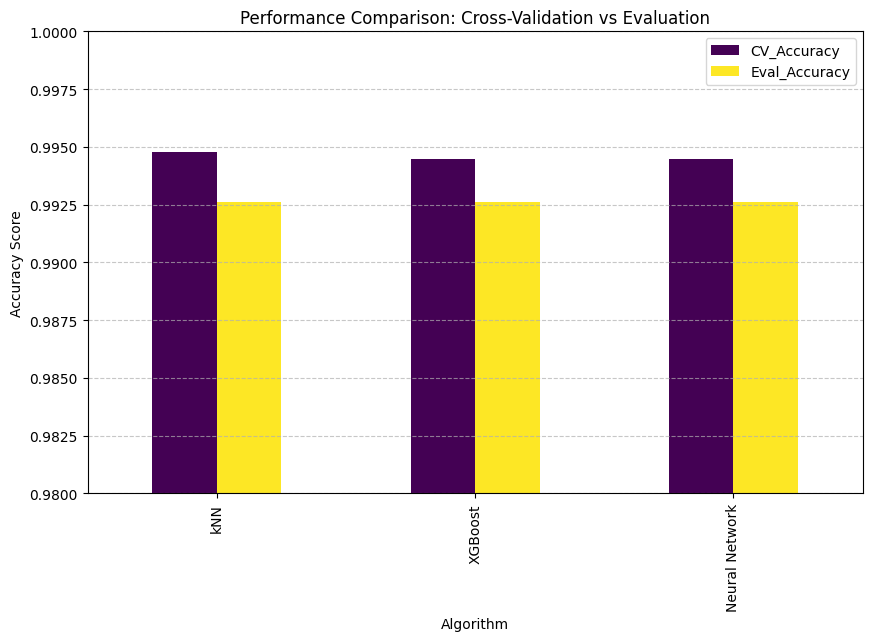

In [ ]:
# 1. รวบรวมผลลัพธ์ (กรอกตัวเลขตามจริงที่คุณรันได้)
results = {
    'Algorithm': ['kNN', 'XGBoost', 'Neural Network'],
    'CV_Accuracy': [grid_knn.best_score_, grid_xgb.best_score_, grid_mlp.best_score_],
    'Eval_Accuracy': [eval_acc, eval_acc_xgb, eval_acc_mlp]
}

df_results = pd.DataFrame(results)
df_results['Delta'] = abs(df_results['CV_Accuracy'] - df_results['Eval_Accuracy'])

# 2. แสดงตารางสรุป
print("--- Summary Performance Table ---")
print(df_results.to_string(index=False))

# 3. พล็อตกราฟเปรียบเทียบ (Bar Chart)
df_results.set_index('Algorithm')[['CV_Accuracy', 'Eval_Accuracy']].plot(kind='bar', figsize=(10,6), cmap='viridis')
plt.title('Performance Comparison: Cross-Validation vs Evaluation')
plt.ylabel('Accuracy Score')
plt.ylim(0.98, 1.0) # ปรับสเกลเพื่อให้เห็นความต่างชัดเจน
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

>กราฟเปรียบเทียบประสิทธิภาพ

กราฟแท่งแสดงการเปรียบเทียบค่าความแม่นยำ (Accuracy) ระหว่างชุดข้อมูลทวนสอบ (5-Fold Cross-Validation) และชุดข้อมูลทดสอบจริง (Evaluation Set) ของทั้ง 3 อัลกอริทึม พบประเด็นวิเคราะห์ที่สำคัญดังนี้

*   การยืนยันสภาวะ Good Fit ของแบบจำลอง

    ค่าความแม่นยำจากทั้งสองชุดข้อมูลมีค่าใกล้เคียงกันมากในทุกโมเดล โดยมีค่าความแตกต่าง (Delta) อยู่ในช่วงเพียง 0.0018 - 0.0022 หรือประมาณ 0.18% - 0.22% ผลลัพธ์ดังกล่าวสะท้อนว่าแบบจำลองมีความสมดุลในการเรียนรู้ข้อมูล กล่าวคือ ไม่เกิดปัญหา Overfitting (การจดจำข้อมูลฝึกสอนมากเกินไป) หรือปัญหา Underfitting เนื่องจากแบบจำลองสามารถทำค่าความแม่นยำได้สูงกว่า 99% ตั้งแต่ขั้นตอนการฝึกสอน

*   ความสามารถในการนำไปใช้งานกับข้อมูลใหม่ (Generalization Ability)

    จากกราฟจะเห็นว่าแท่งกราฟของ Evaluation Accuracy มีความสูงใกล้เคียงกับแท่ง Cross-Validation Accuracy ในทุกโมเดล แสดงให้เห็นว่าแบบจำลองสามารถนำความรู้ที่เรียนรู้จากข้อมูลฝึกสอนไปใช้พยากรณ์ข้อมูลที่ไม่เคยเห็นมาก่อนได้อย่างมีประสิทธิภาพและเสถียร


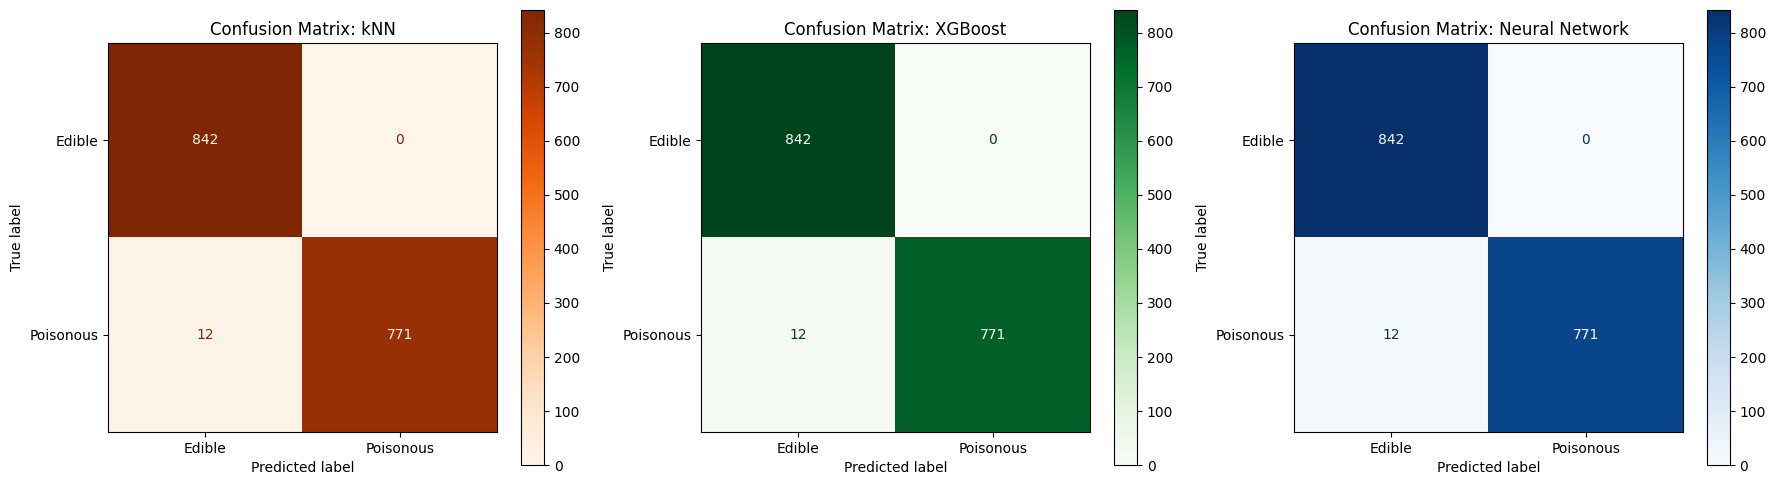

In [ ]:
# เตรียมข้อมูลความผิดพลาดของทั้ง 3 โมเดล
models = [
    ('kNN', y_pred),           # y_pred จาก kNN
    ('XGBoost', y_pred_xgb),    # y_pred จาก XGBoost
    ('Neural Network', y_pred_mlp) # y_pred จาก MLP
]

# สร้างพื้นที่สำหรับ 3 กราฟเรียงกัน
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, pred) in enumerate(models):
    cm = confusion_matrix(y_eval, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Edible', 'Poisonous'])

    # วาดกราฟในช่องที่กำหนด
    disp.plot(ax=axes[i], cmap='Oranges' if name == 'kNN' else ('Greens' if name == 'XGBoost' else 'Blues'))
    axes[i].set_title(f'Confusion Matrix: {name}'

plt.tight_layout()
plt.show()

>เมทริกซ์ความสับสนของทั้ง 3 แบบจำลอง (Confusion Matrix Analysis)

จากการพิจารณาเมทริกซ์ความสับสน (Confusion Matrix) ของชุดข้อมูลทดสอบจำนวน 1,625 ตัวอย่าง พบว่าแบบจำลองทั้งสาม ได้แก่ k-Nearest Neighbors (kNN), XGBoost และ Neural Network ให้รูปแบบการพยากรณ์ที่สอดคล้องกันอย่างชัดเจน โดยสามารถวิเคราะห์ผลลัพธ์ที่สำคัญได้ดังนี้

1. ความแม่นยำด้านความปลอดภัยของการจำแนก (Zero False Positive)

    จากเมทริกซ์ความสับสนพบว่า ช่อง False Positive ของทุกโมเดลมีค่าเท่ากับ 0 หมายความว่าไม่มีกรณีที่ระบบพยากรณ์ว่าเห็ดเป็นพิษ (Poisonous) ทั้งที่จริงแล้วเป็นเห็ดกินได้ (Edible) ผลลัพธ์ดังกล่าวส่งผลให้ค่า Precision สำหรับคลาสเห็ดพิษเท่ากับ 1.00 (100%) ซึ่งถือว่าเป็นคุณสมบัติที่มีความสำคัญอย่างยิ่งในบริบทของการใช้งานจริง เนื่องจากช่วยป้องกันการแจ้งเตือนผิดพลาดที่อาจนำไปสู่การทิ้งเห็ดที่สามารถบริโภคได้โดยไม่จำเป็น

2. การวิเคราะห์ความสามารถในการตรวจจับเห็ดพิษ (Recall Analysis)

    จากข้อมูลในเมทริกซ์ความสับสน พบว่าโมเดลสามารถจำแนก เห็ดพิษได้ถูกต้องจำนวน 771 ตัวอย่าง จากทั้งหมด 783 ตัวอย่าง และมีกรณีที่พยากรณ์ผิดเป็นเห็ดกินได้จำนวน 12 ตัวอย่าง (False Negative) ผลลัพธ์ดังกล่าวทำให้ค่า Recall สำหรับคลาสเห็ดพิษอยู่ที่ประมาณ 0.98 (98%) ซึ่งแสดงให้เห็นว่าแบบจำลองสามารถตรวจจับเห็ดพิษได้ครอบคลุมในระดับที่สูงมาก โดยมีเพียงส่วนน้อยเท่านั้นที่หลุดรอดจากการตรวจจับ



---

